# **Data Warehouse: MotoGP Race Results (2022-2025)**
**Proyek:** UTS

**Mata Kuliah:** Business Intelligence

**Dataset:** [MotoGP Race Results (2022-2025)](https://www.kaggle.com/datasets/sammee/motogp-race-results-2022?select=Qualifying.csv)

---


## **Deskripsi Tugas**
Notebook ini memuat proses lengkap **Extract, Transform, Load (ETL)** untuk membangun data warehouse dari dataset MotoGP Race Results (2022-2025).

## **Alur Proyek**
1. Desain Data Warehouse (Star Schema Modeling)
2. Extract
3. Transform
4. Load
5. Analisis

# **Import Library**

In [ ]:
import pandas as pd
import numpy as np
import sqlite3
import os
import warnings
warnings.filterwarnings('ignore')

import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

plt.style.use('dark_background')

neon_colors = [
  "#00FFFF",
  "#FF00FF",
  "#39FF14",
  "#FF073A",
  "#FFD700",
]

sns.set_palette(neon_colors)

# **Load Dataset (Extract)**

In [ ]:
from google.colab import files
uploaded = files.upload()

KeyboardInterrupt: 

In [ ]:
race = pd.read_csv('Race.csv')
qualifying = pd.read_csv('Qualifying.csv')

# **Data Understanding**

**Overview Dataset**

In [ ]:
print('='*60)
print('DATA UNDERSTANDING - MOTOGP DATASET')
print('='*60)

print('\nJumlah Data Race   :', race.shape[0], 'baris,', race.shape[1], 'kolom')
print('Jumlah Data Qualifying :', qualifying.shape[0], 'baris,', qualifying.shape[1], 'kolom')

DATA UNDERSTANDING - MOTOGP DATASET

Jumlah Data Race   : 8621 baris, 12 kolom
Jumlah Data Qualifying : 8019 baris, 12 kolom


**Informasi Seluruh Data**

In [ ]:
print('='*60)
print('INFO DATASET - RACE')
print('='*60)
race.info()

print('\n' + '='*60)
print('INFO DATASET - QUALIFYING')
print('='*60)
qualifying.info()

INFO DATASET - RACE
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8621 entries, 0 to 8620
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   result_id   8621 non-null   int64  
 1   pos.        8621 non-null   object 
 2   pts         8621 non-null   float64
 3   no          8621 non-null   int64  
 4   rider       8621 non-null   object 
 5   Team        8621 non-null   object 
 6   time / gap  8402 non-null   object 
 7   session     8621 non-null   object 
 8   class       8621 non-null   object 
 9   event       8621 non-null   object 
 10  year        8621 non-null   int64  
 11  event_id    8621 non-null   int64  
dtypes: float64(1), int64(4), object(7)
memory usage: 808.3+ KB

INFO DATASET - QUALIFYING
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8019 entries, 0 to 8018
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   result

**Check Missing Values**

In [ ]:
print('='*60)
print('MISSING VALUES - RACE')
print('='*60)

missing_race = race.isnull().sum()
missing_pct_race = (missing_race / len(race) * 100).round(2)

missing_df_race = pd.DataFrame({
    'Missing': missing_race,
    'Persen (%)': missing_pct_race
})

print(missing_df_race[missing_df_race['Missing'] > 0])


print('\n' + '='*60)
print('MISSING VALUES - QUALIFYING')
print('='*60)

missing_qual = qualifying.isnull().sum()
missing_pct_qual = (missing_qual / len(qualifying) * 100).round(2)

missing_df_qual = pd.DataFrame({
    'Missing': missing_qual,
    'Persen (%)': missing_pct_qual
})

print(missing_df_qual[missing_df_qual['Missing'] > 0])

MISSING VALUES - RACE
            Missing  Persen (%)
time / gap      219        2.54

MISSING VALUES - QUALIFYING
                 Missing  Persen (%)
gap 1st / prev.      658        8.21
time                 118        1.47


**Statistik Deskriptif**

In [ ]:
print('='*60)
print('STATISTIK DESKRIPTIF - RACE')
print('='*60)
print(race.describe())

print('\n' + '='*60)
print('STATISTIK DESKRIPTIF - QUALIFYING')
print('='*60)
print(qualifying.describe())

STATISTIK DESKRIPTIF - RACE
         result_id          pts           no         year     event_id
count  8621.000000  8621.000000  8621.000000  8621.000000  8621.000000
mean   4310.000000     5.017979    41.046166  2023.590187     9.675444
std    2488.812669     6.525901    28.333909     1.105099     5.783105
min       0.000000     0.000000     1.000000  2022.000000     0.000000
25%    2155.000000     0.000000    18.000000  2023.000000     5.000000
50%    4310.000000     2.000000    35.000000  2024.000000    10.000000
75%    6465.000000     8.000000    66.000000  2025.000000    14.000000
max    8620.000000    25.000000    99.000000  2025.000000    21.000000

STATISTIK DESKRIPTIF - QUALIFYING
         result_id         pos.           no         year     event_id
count  8019.000000  8019.000000  8019.000000  8019.000000  8019.000000
mean   4009.000000     7.986407    41.235566  2023.524255     9.707320
std    2315.030237     4.623051    28.777321     1.132197     5.788878
min       0.00

**Sample Data**

In [ ]:
print('='*60)
print('SAMPLE DATA RACE')
print('='*60)
display(race.head())

print('\n' + '='*60)
print('SAMPLE DATA QUALIFYING')
print('='*60)
display(qualifying.head())

SAMPLE DATA RACE


,result_id,pos.,pts,no,rider,Team,time / gap,session,class,event,year,event_id
0,0,1,25.0,13,C. Vietti,Mooney VR46 Racing Team,39:53.637,Race,Moto2,QAT,2022,0
1,1,2,20.0,40,A. Canet,Flexbox HP40,+6.154,Race,Moto2,QAT,2022,0
2,2,3,16.0,22,S. Lowes,Elf Marc VDS Racing Team,+10.181,Race,Moto2,QAT,2022,0
3,3,4,13.0,37,A. Fernandez,Red Bull KTM Ajo,+10.259,Race,Moto2,QAT,2022,0
4,4,5,11.0,14,T. Arbolino,Elf Marc VDS Racing Team,+11.421,Race,Moto2,QAT,2022,0



SAMPLE DATA QUALIFYING


,result_id,pos.,no,rider,Team,gap 1st / prev.,time,session,class,event,year,event_id
0,0,1,75,A. Arenas,Inde GASGAS Aspar Team,NaN,01:59.371,Q1,Moto2,QAT,2022,0
1,1,2,54,F. Aldeguer,MB Conveyors Speed Up,+0.319 / +0.319,01:59.690,Q1,Moto2,QAT,2022,0
2,2,3,64,B. Bendsneyder,Pertamina Mandalika SAG Team,+0.378 / +0.059,01:59.749,Q1,Moto2,QAT,2022,0
3,3,4,7,B. Baltus,RW Racing GP,+0.508 / +0.130,01:59.879,Q1,Moto2,QAT,2022,0
4,4,5,24,S. Corsi,MV Agusta Forward Racing,+0.692 / +0.184,02:00.063,Q1,Moto2,QAT,2022,0


# **Data Cleaning (Transform)**

**Standarisasi Nama Kolom**

In [ ]:
print('='*60)
print('SEBELUM RENAME (RACE)')
print('='*60)
print(race.columns)

print('\nSEBELUM RENAME (QUALIFYING)')
print('='*60)
print(qualifying.columns)


race = race.rename(columns={
    'pos.': 'position',
    'pts': 'points',
    'time / gap': 'time_gap',
    'Team': 'team'
})

qualifying = qualifying.rename(columns={
    'pos.': 'position',
    'time': 'lap_time',
    'gap 1st / prev.': 'gap',
    'Team': 'team'
})


print('\n' + '='*60)
print('SESUDAH RENAME (RACE)')
print('='*60)
print(race.columns)

print('\nSESUDAH RENAME (QUALIFYING)')
print('='*60)
print(qualifying.columns)

SEBELUM RENAME (RACE)
Index(['result_id', 'pos.', 'pts', 'no', 'rider', 'Team', 'time / gap',
       'session', 'class', 'event', 'year', 'event_id'],
      dtype='object')

SEBELUM RENAME (QUALIFYING)
Index(['result_id', 'pos.', 'no', 'rider', 'Team', 'gap 1st / prev.', 'time',
       'session', 'class', 'event', 'year', 'event_id'],
      dtype='object')

SESUDAH RENAME (RACE)
Index(['result_id', 'position', 'points', 'no', 'rider', 'team', 'time_gap',
       'session', 'class', 'event', 'year', 'event_id'],
      dtype='object')

SESUDAH RENAME (QUALIFYING)
Index(['result_id', 'position', 'no', 'rider', 'team', 'gap', 'lap_time',
       'session', 'class', 'event', 'year', 'event_id'],
      dtype='object')


**Membersihkan Spasi**

In [ ]:
print('\n' + '='*60)
print('SEBELUM CLEAN STRING (RACE SAMPLE)')
print('='*60)
display(race[['rider','team']].head())


race = race.applymap(lambda x: x.strip() if isinstance(x, str) else x)
qualifying = qualifying.applymap(lambda x: x.strip() if isinstance(x, str) else x)


print('\nSESUDAH CLEAN STRING (RACE SAMPLE)')
print('='*60)
display(race[['rider','team']].head())


SEBELUM CLEAN STRING (RACE SAMPLE)


,rider,team
0,C. Vietti,Mooney VR46 Racing Team
1,A. Canet,Flexbox HP40
2,S. Lowes,Elf Marc VDS Racing Team
3,A. Fernandez,Red Bull KTM Ajo
4,T. Arbolino,Elf Marc VDS Racing Team



SESUDAH CLEAN STRING (RACE SAMPLE)


,rider,team
0,C. Vietti,Mooney VR46 Racing Team
1,A. Canet,Flexbox HP40
2,S. Lowes,Elf Marc VDS Racing Team
3,A. Fernandez,Red Bull KTM Ajo
4,T. Arbolino,Elf Marc VDS Racing Team


**Missing Values**

In [ ]:
print('='*60)
print('MISSING VALUES SEBELUM (RACE)')
print('='*60)
print(race.isnull().sum())

print('\nMISSING VALUES SEBELUM (QUALIFYING)')
print('='*60)
print(qualifying.isnull().sum())


race['position'] = pd.to_numeric(race['position'], errors='coerce')
qualifying['position'] = pd.to_numeric(qualifying['position'], errors='coerce')

race['points'] = pd.to_numeric(race['points'], errors='coerce')
race['points'] = race['points'].fillna(0)

race['race_status'] = race['position'].apply(
    lambda x: 'FINISH' if pd.notnull(x) else 'DNF/DNS'
)


print('\n' + '='*60)
print('MISSING VALUES SESUDAH (RACE)')
print('='*60)
print(race.isnull().sum())

print('\nMISSING VALUES SESUDAH (QUALIFYING)')
print('='*60)
print(qualifying.isnull().sum())


print('\n' + '='*60)
print('SAMPLE DATA SETELAH HANDLING')
print('='*60)
display(race[['rider','position','points','race_status']].head())

MISSING VALUES SEBELUM (RACE)
result_id      0
position       0
points         0
no             0
rider          0
team           0
time_gap     219
session        0
class          0
event          0
year           0
event_id       0
dtype: int64

MISSING VALUES SEBELUM (QUALIFYING)
result_id      0
position       0
no             0
rider          0
team           0
gap          658
lap_time     118
session        0
class          0
event          0
year           0
event_id       0
dtype: int64

MISSING VALUES SESUDAH (RACE)
result_id         0
position       1498
points            0
no                0
rider             0
team              0
time_gap        219
session           0
class             0
event             0
year              0
event_id          0
race_status       0
dtype: int64

MISSING VALUES SESUDAH (QUALIFYING)
result_id      0
position       0
no             0
rider          0
team           0
gap          658
lap_time     118
session        0
class          0
event

,rider,position,points,race_status
0,C. Vietti,1.0,25.0,FINISH
1,A. Canet,2.0,20.0,FINISH
2,S. Lowes,3.0,16.0,FINISH
3,A. Fernandez,4.0,13.0,FINISH
4,T. Arbolino,5.0,11.0,FINISH


**Data Duplicate**

In [ ]:
print('='*60)
print('JUMLAH DUPLIKAT (RACE)')
print('='*60)
print(race.duplicated().sum())

print('\nJUMLAH DUPLIKAT (QUALIFYING)')
print('='*60)
print(qualifying.duplicated().sum())

print('\nTidak ada data yang duplikat')

JUMLAH DUPLIKAT (RACE)
0

JUMLAH DUPLIKAT (QUALIFYING)
0

Tidak ada data yang duplikat


**Pembuatan Dimensi Table**

dim_rider

In [ ]:
print('='*60)
print('DIM_RIDER SEBELUM')
print('='*60)
display(race[['rider','no']].head())


dim_rider = pd.concat([
    race[['rider','no']],
    qualifying[['rider','no']]
]).drop_duplicates()

dim_rider.columns = ['rider_name', 'rider_number']


print('\nDIM_RIDER SESUDAH')
print('='*60)
display(dim_rider.head())
print('Total rider:', len(dim_rider))

DIM_RIDER SEBELUM


,rider,no
0,C. Vietti,13
1,A. Canet,40
2,S. Lowes,22
3,A. Fernandez,37
4,T. Arbolino,14



DIM_RIDER SESUDAH


,rider_name,rider_number
0,C. Vietti,13
1,A. Canet,40
2,S. Lowes,22
3,A. Fernandez,37
4,T. Arbolino,14


Total rider: 265


dim_team

In [ ]:
dim_team = pd.concat([
    race[['team']],
    qualifying[['team']]
]).dropna().drop_duplicates()

dim_team['team_name'] = dim_team['team'].astype(str).str.strip()
dim_team = dim_team[['team_name']].drop_duplicates()
dim_team['team_id'] = range(1, len(dim_team) + 1)

print('\nDIM_TEAM')
print('='*60)
display(dim_team.head())


DIM_TEAM


,team_name,team_id
0,Mooney VR46 Racing Team,1
1,Flexbox HP40,2
2,Elf Marc VDS Racing Team,3
3,Red Bull KTM Ajo,4
5,IDEMITSU Honda Team Asia,5


dim_event

In [ ]:
dim_event = pd.concat([
    race[['event', 'class']],
    qualifying[['event', 'class']]
]).dropna().drop_duplicates()

dim_event['event_name'] = dim_event['event'].astype(str).str.strip()
dim_event['class'] = dim_event['class'].astype(str).str.strip()
dim_event = dim_event[['event_name', 'class']].drop_duplicates()
dim_event['event_id'] = range(1, len(dim_event) + 1)

print('\nDIM_EVENT RE-CREATED')
display(dim_event.head())


DIM_EVENT RE-CREATED


,event_name,class,event_id
0,QAT,Moto2,1
29,QAT,Moto3,2
58,QAT,MotoGP,3
82,INA,Moto2,4
111,INA,Moto3,5


dim_time

In [ ]:
dim_time = pd.concat([
    race[['year']],
    qualifying[['year']]
]).drop_duplicates()

dim_time['season'] = dim_time['year']

print('\nDIM_TIME')
print('='*60)
display(dim_time.head())


DIM_TIME


,year,season
0,2022,2022
1882,2023,2023
3990,2024,2024
6282,2025,2025


**Tambah Surrogate Key**

In [ ]:
dim_rider['rider_id'] = range(1, len(dim_rider)+1)
dim_team['team_id'] = range(1, len(dim_team)+1)
dim_event['event_id'] = range(1, len(dim_event)+1)
dim_time['time_id'] = range(1, len(dim_time)+1)

print('\nDIM_RIDER + ID')
display(dim_rider.head())


DIM_RIDER + ID


,rider_name,rider_number,rider_id
0,C. Vietti,13,1
1,A. Canet,40,2
2,S. Lowes,22,3
3,A. Fernandez,37,4
4,T. Arbolino,14,5


**Pembuatan Fact Table**

Fact Race

In [ ]:
race['event'] = race['event'].astype(str).str.strip().str.upper()
race['class'] = race['class'].astype(str).str.strip().str.upper()

dim_event['event_name'] = dim_event['event_name'].astype(str).str.strip().str.upper()
dim_event['class'] = dim_event['class'].astype(str).str.strip().str.upper()

fact_race = race.merge(dim_rider, left_on='rider', right_on='rider_name', how='left')
fact_race = fact_race.merge(dim_team, left_on='team', right_on='team_name', how='left')
fact_race = fact_race.merge(dim_event, left_on=['event', 'class'], right_on=['event_name', 'class'], how='left')
fact_race = fact_race.merge(dim_time, on='year', how='left')

print("Kolom yang tersedia di fact_race:", fact_race.columns.tolist())

final_cols = ['rider_id', 'team_id', 'event_id_y', 'time_id', 'position', 'points', 'time_gap']
fact_race_final = fact_race[[col for col in final_cols if col in fact_race.columns]]
fact_race_final = fact_race_final.rename(columns={'event_id_y': 'event_id'})

print('\nFACT RACE FINAL SAMPLE')
display(fact_race_final.head())

Kolom yang tersedia di fact_race: ['result_id', 'position', 'points', 'no', 'rider', 'team', 'time_gap', 'session', 'class', 'event', 'year', 'event_id_x', 'race_status', 'rider_name', 'rider_number', 'rider_id', 'team_name', 'team_id', 'event_name', 'event_id_y', 'season', 'time_id']

FACT RACE FINAL SAMPLE


,rider_id,team_id,event_id,time_id,position,points,time_gap
0,1,NaN,1,1,1.0,25.0,39:53.637
1,2,NaN,1,1,2.0,20.0,+6.154
2,185,NaN,1,1,2.0,20.0,+6.154
3,3,NaN,1,1,3.0,16.0,+10.181
4,4,NaN,1,1,4.0,13.0,+10.259


Fact Qualifying

In [ ]:
qualifying['event'] = qualifying['event'].astype(str).str.strip().str.upper()
qualifying['class'] = qualifying['class'].astype(str).str.strip().str.upper()
qualifying['team'] = qualifying['team'].astype(str).str.strip().str.upper()

dim_team['team_name'] = dim_team['team_name'].astype(str).str.strip().str.upper()

fact_qualifying = qualifying.merge(dim_rider, left_on='rider', right_on='rider_name', how='left')
fact_qualifying = fact_qualifying.merge(dim_team, left_on='team', right_on='team_name', how='left')
fact_qualifying = fact_qualifying.merge(dim_event, left_on=['event', 'class'], right_on=['event_name', 'class'], how='left')
fact_qualifying = fact_qualifying.merge(dim_time, on='year', how='left')

final_cols_qual = ['rider_id', 'team_id', 'event_id_y', 'time_id', 'position', 'lap_time', 'gap']
fact_qualifying_final = fact_qualifying[[col for col in final_cols_qual if col in fact_qualifying.columns]]
fact_qualifying_final = fact_qualifying_final.rename(columns={'event_id_y': 'event_id'})

print('\nFACT QUALIFYING FINAL SAMPLE')
display(fact_qualifying_final.head())


FACT QUALIFYING FINAL SAMPLE


,rider_id,team_id,event_id,time_id,position,lap_time,gap
0,13,9,1,1,1,01:59.371,NaN
1,16,10,1,1,2,01:59.690,+0.319 / +0.319
2,19,12,1,1,3,01:59.749,+0.378 / +0.059
3,27,15,1,1,4,01:59.879,+0.508 / +0.130
4,18,11,1,1,5,02:00.063,+0.692 / +0.184


**Ringkasan Hasil Transform**

In [ ]:
print('='*60)
print('RINGKASAN HASIL TRANSFORM')
print('='*60)

print('\n[DATASET AWAL]')
print(f'  Total Race Records        : {len(race)}')
print(f'  Total Qualifying Records  : {len(qualifying)}')

print('\n[DIMENSION TABLE]')
print(f'  Total Rider   : {len(dim_rider)}')
print(f'  Total Team    : {len(dim_team)}')
print(f'  Total Event   : {len(dim_event)}')
print(f'  Total Time    : {len(dim_time)}')

print('\n[FACT TABLE]')
print(f'  Total Race Fact        : {len(fact_race_final)}')
print(f'  Total Qualifying Fact  : {len(fact_qualifying_final)}')

print('\n[MISSING VALUES]')
print(f'  Missing Race Data        : {race.isnull().sum().sum()}')
print(f'  Missing Qualifying Data  : {qualifying.isnull().sum().sum()}')

print('\n[RANGE DATA]')
print(f'  Tahun Data : {dim_time["year"].min()} – {dim_time["year"].max()}')

print('\n[UNIQUE VALUES]')
print(f'  Jumlah Rider Unik : {dim_rider["rider_name"].nunique()}')
print(f'  Jumlah Team Unik  : {dim_team["team_name"].nunique()}')
print(f'  Jumlah Event Unik : {dim_event["event_name"].nunique()}')

print('='*60)

print('\nSAMPLE FACT RACE')
display(fact_race_final.head(3))

print('\nSAMPLE FACT QUALIFYING')
display(fact_qualifying_final.head(3))

RINGKASAN HASIL TRANSFORM - MOTOGP DATA WAREHOUSE

[DATASET AWAL]
  Total Race Records        : 8621
  Total Qualifying Records  : 8019

[DIMENSION TABLE]
  Total Rider   : 265
  Total Team    : 187
  Total Event   : 86
  Total Time    : 4

[FACT TABLE]
  Total Race Fact        : 11489
  Total Qualifying Fact  : 11936

[MISSING VALUES]
  Missing Race Data        : 1717
  Missing Qualifying Data  : 776

[RANGE DATA]
  Tahun Data : 2022 – 2025

[UNIQUE VALUES]
  Jumlah Rider Unik : 212
  Jumlah Team Unik  : 177
  Jumlah Event Unik : 25

SAMPLE FACT RACE


,rider_id,team_id,time_id,position,points,time_gap
0,1,1,1,1.0,25.0,39:53.637
1,2,2,1,2.0,20.0,+6.154
2,185,2,1,2.0,20.0,+6.154



SAMPLE FACT QUALIFYING


,rider_id,team_id,time_id,position,lap_time,gap
0,13,9,1,1,01:59.371,NaN
1,16,10,1,2,01:59.690,+0.319 / +0.319
2,19,12,1,3,01:59.749,+0.378 / +0.059


# **Membangun Data Warehouse Menggunakan Star Schema (Load)**

Database yang digunakan: SQLite

                     ┌──────────────┐
                     │   dim_time   │
                     └──────┬───────┘
                            │
        ┌─────────────┐     │     ┌──────────────┐
        │  dim_rider  ├─────┼─────┤   dim_team   │
        └─────────────┘     │     └──────────────┘
                            ▼
               ┌──────────────────────────┐
               │   fact_race_results      │
               └───────────▲──────────────┘
                           │
               ┌──────────────────────────┐
               │ fact_qualifying_results  │
               └───────────▲──────────────┘
                           │
                     ┌──────────────┐
                     │  dim_event   │
                     └──────────────┘

**Setup Database**

In [ ]:
conn = sqlite3.connect('motogp_datawarehouse.db')
cursor = conn.cursor()

# Drop tables jika sudah ada (untuk re-run)
tables = [
    'fact_race_results',
    'fact_qualifying_results',
    'dim_rider',
    'dim_team',
    'dim_event',
    'dim_time'
]

for t in tables:
    cursor.execute(f'DROP TABLE IF EXISTS {t}')

conn.commit()
print('Koneksi SQLite berhasil dibuat: motogp_datawarehouse.db')

Koneksi SQLite berhasil dibuat: motogp_datawarehouse.db


**Create Table**

Dimension Table

In [ ]:
cursor.execute("""
CREATE TABLE dim_rider (
    rider_id INTEGER PRIMARY KEY,
    rider_name TEXT,
    rider_number INTEGER
)
""")

cursor.execute("""
CREATE TABLE dim_team (
    team_id INTEGER PRIMARY KEY,
    team_name TEXT
)
""")

cursor.execute("""
CREATE TABLE dim_event (
    event_id INTEGER PRIMARY KEY,
    event_name TEXT,
    class TEXT
)
""")

cursor.execute("""
CREATE TABLE dim_time (
    time_id INTEGER PRIMARY KEY,
    year INTEGER,
    season INTEGER
)
""")

Fact Table

In [ ]:
cursor.execute("""
CREATE TABLE fact_race_results (
    result_id INTEGER PRIMARY KEY AUTOINCREMENT,
    rider_id INTEGER,
    team_id INTEGER,
    event_id INTEGER,
    time_id INTEGER,
    position INTEGER,
    points INTEGER,
    time_gap TEXT
)
""")

cursor.execute("""
CREATE TABLE fact_qualifying_results (
    result_id INTEGER PRIMARY KEY AUTOINCREMENT,
    rider_id INTEGER,
    team_id INTEGER,
    event_id INTEGER,
    time_id INTEGER,
    position INTEGER,
    lap_time TEXT,
    gap TEXT
)
""")

conn.commit()
print('Semua tabel berhasil dibuat')

Semua tabel berhasil dibuat


**Insert Data Table**

Dimension Table

In [ ]:
dim_rider.to_sql('dim_rider', conn, if_exists='append', index=False)
print(f'dim_rider            → {len(dim_rider)} baris')

dim_team.to_sql('dim_team', conn, if_exists='append', index=False)
print(f'dim_team             → {len(dim_team)} baris')

dim_event.to_sql('dim_event', conn, if_exists='append', index=False)
print(f'dim_event            → {len(dim_event)} baris')

dim_time.to_sql('dim_time', conn, if_exists='append', index=False)
print(f'dim_time             → {len(dim_time)} baris')

dim_rider            → 265 baris
dim_team             → 187 baris
dim_event            → 86 baris
dim_time             → 4 baris


Fact Table

In [ ]:
fact_race_final.to_sql('fact_race_results', conn, if_exists='append', index=False)
print(f'fact_race_results    → {len(fact_race_final)} baris')

fact_qualifying_final.to_sql('fact_qualifying_results', conn, if_exists='append', index=False)
print(f'fact_qualifying      → {len(fact_qualifying_final)} baris')

fact_race_results    → 11489 baris
fact_qualifying      → 11936 baris


**Validasi Table**

In [ ]:
print('\n' + '='*60)
print('DATA WAREHOUSE MOTOGP BERHASIL DIBANGUN!')
print('='*60)

for t in tables:
    count = cursor.execute(f'SELECT COUNT(*) FROM {t}').fetchone()[0]
    print(f'  {t:<30}: {count:>5} baris')


print('\n📋 Schema fact_race_results:')
schema = cursor.execute('PRAGMA table_info(fact_race_results)').fetchall()

import pandas as pd
schema_df = pd.DataFrame(schema, columns=['cid','name','type','notnull','default','pk'])
print(schema_df[['name','type']].to_string(index=False))


DATA WAREHOUSE MOTOGP BERHASIL DIBANGUN!
  fact_race_results             : 11489 baris
  fact_qualifying_results       : 11936 baris
  dim_rider                     :   265 baris
  dim_team                      :   187 baris
  dim_event                     :    86 baris
  dim_time                      :     4 baris

📋 Schema fact_race_results:
     name    type
result_id INTEGER
 rider_id INTEGER
  team_id INTEGER
 event_id INTEGER
  time_id INTEGER
 position INTEGER
   points INTEGER
 time_gap    TEXT


**Export Data Warehouse ke CSV**

In [ ]:
base_path = '/content/motogp_dw_output'
os.makedirs(base_path, exist_ok=True)

tables_export = {
    'rider_dimension': dim_rider,
    'team_dimension': dim_team,
    'event_dimension': dim_event,
    'time_dimension': dim_time,
    'race_fact': fact_race_final,
    'qualifying_fact': fact_qualifying_final
}

print('Proses export ke CSV dimulai...\n')

for name, df in tables_export.items():
    file_path = os.path.join(base_path, f'{name}.csv')
    df.to_csv(file_path, index=False)

    print(f'{name:<20} → {df.shape[0]} baris, {df.shape[1]} kolom')

print('\n' + '='*55)
print('Semua file berhasil disimpan di:')
print(base_path)
print('='*55)

Proses export ke CSV dimulai...

rider_dimension      → 265 baris, 3 kolom
team_dimension       → 187 baris, 2 kolom
event_dimension      → 86 baris, 3 kolom
time_dimension       → 4 baris, 3 kolom
race_fact            → 11489 baris, 7 kolom
qualifying_fact      → 11936 baris, 7 kolom

Semua file berhasil disimpan di:
/content/motogp_dw_output


# **Analisis Data**

**Top Rider**

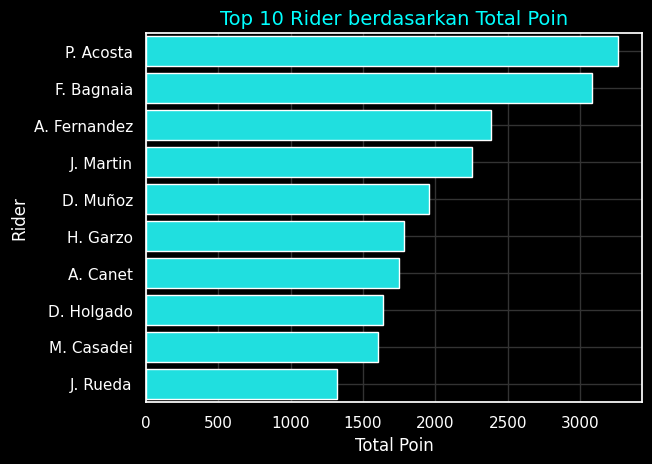

In [ ]:
query = """
SELECT dr.rider_name, SUM(fr.points) AS total_points
FROM fact_race_results fr
JOIN dim_rider dr ON fr.rider_id = dr.rider_id
GROUP BY dr.rider_name
ORDER BY total_points DESC
LIMIT 10
"""
df = pd.read_sql(query, conn)

plt.figure()
sns.barplot(data=df, x='total_points', y='rider_name')

plt.title('Top 10 Rider berdasarkan Total Poin', color='#00FFFF', fontsize=14)
plt.xlabel('Total Poin', color='white')
plt.ylabel('Rider', color='white')

plt.grid(color='#333333')
plt.show()

Pembalap dengan total poin tertinggi menunjukkan konsistensi performa sepanjang musim dan menjadi kandidat utama juara

**Top Team**

In [ ]:
query = """
SELECT dt.team_name, SUM(fr.points) AS total_points
FROM fact_race_results fr
JOIN dim_team dt ON fr.team_id = dt.team_id
GROUP BY dt.team_name
ORDER BY total_points DESC
LIMIT 10
"""
df = pd.read_sql(query, conn)

fig = px.bar(
    df,
    x='team_name',
    y='total_points',
    title='Total Poin per Team',
    color='total_points',
    color_continuous_scale=['#00FFFF', '#FF00FF']
)

fig.update_layout(
    plot_bgcolor='black',
    paper_bgcolor='black',
    font=dict(color='white')
)

fig.show()

Tim dengan poin tertinggi menunjukkan performa kolektif yang kuat serta strategi dan konsistensi yang baik sepanjang musim

**Tren Performa**

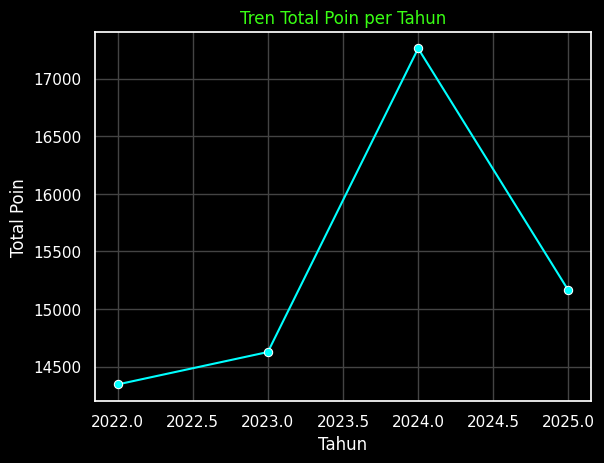

In [ ]:
query = """
SELECT dt.year, SUM(fr.points) AS total_points
FROM fact_race_results fr
JOIN dim_time dt ON fr.time_id = dt.time_id
GROUP BY dt.year
ORDER BY dt.year
"""
df = pd.read_sql(query, conn)

plt.figure()
sns.lineplot(data=df, x='year', y='total_points', marker='o')

plt.title('Tren Total Poin per Tahun', color='#39FF14')
plt.xlabel('Tahun', color='white')
plt.ylabel('Total Poin', color='white')

plt.grid(color='#444444')
plt.show()

Tren poin per tahun menunjukkan dinamika kompetisi, di mana peningkatan atau penurunan dapat mencerminkan perubahan performa tim dan pembalap

**START vs FINISH**

In [ ]:
query = """
SELECT
    fq.position AS start_pos,
    AVG(fr.position) AS finish_pos
FROM fact_race_results fr
JOIN fact_qualifying_results fq
ON fr.rider_id = fq.rider_id
AND fr.time_id = fq.time_id
WHERE fr.position IS NOT NULL
GROUP BY fq.position
ORDER BY fq.position
"""
df = pd.read_sql(query, conn)

fig = px.line(
    df,
    x='start_pos',
    y='finish_pos',
    title='Rata-rata Finish Position berdasarkan Start Position',
    markers=True
)

fig.update_layout(
    plot_bgcolor='black',
    paper_bgcolor='black',
    font=dict(color='white')
)

fig.show()

Grafik menunjukkan bahwa semakin depan posisi start, semakin kecil (lebih baik) rata-rata posisi finish. Hal ini mengindikasikan bahwa hasil kualifikasi memiliki pengaruh signifikan terhadap hasil balapan.

**Distribusi Kemenangan**

In [ ]:
query = """
SELECT dt.team_name, COUNT(*) AS wins
FROM fact_race_results fr
JOIN dim_team dt ON fr.team_id = dt.team_id
WHERE fr.position = 1
GROUP BY dt.team_name
LIMIT 10
"""
df = pd.read_sql(query, conn)

fig = px.pie(
    df,
    names='team_name',
    values='wins',
    title='Distribusi Kemenangan per Team',
    color_discrete_sequence=neon_colors
)

fig.update_layout(
    paper_bgcolor='black',
    font=dict(color='white')
)

fig.show()

Distribusi kemenangan menunjukkan dominasi tim tertentu dalam kompetisi, di mana tim dengan proporsi kemenangan terbesar memiliki keunggulan performa yang signifikan

**Konsisten Rider**

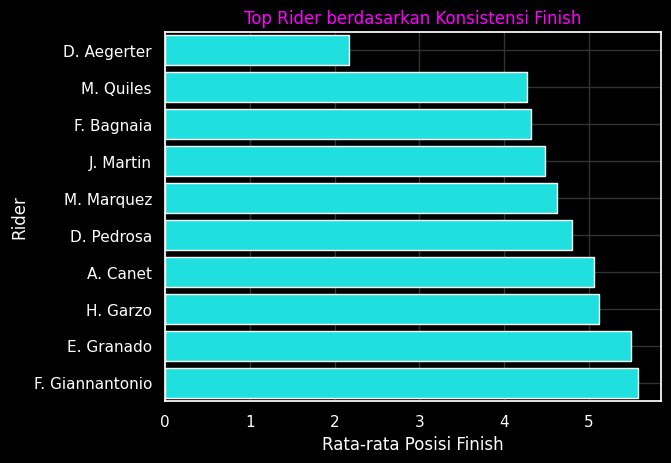

In [ ]:
query = """
SELECT dr.rider_name, AVG(fr.position) AS avg_finish
FROM fact_race_results fr
JOIN dim_rider dr ON fr.rider_id = dr.rider_id
WHERE fr.position IS NOT NULL
GROUP BY dr.rider_name
ORDER BY avg_finish ASC
LIMIT 10
"""
df = pd.read_sql(query, conn)

df = df.sort_values(by='avg_finish', ascending=True)

plt.figure()
sns.barplot(data=df, x='avg_finish', y='rider_name')

plt.title('Top Rider berdasarkan Konsistensi Finish', color='#FF00FF')
plt.xlabel('Rata-rata Posisi Finish', color='white')
plt.ylabel('Rider', color='white')

plt.grid(color='#333333')
plt.show()

Pembalap dengan rata-rata posisi finish terendah menunjukkan tingkat konsistensi yang tinggi dalam mempertahankan performa di setiap balapan

# **Kesimpulan & Insight**

In [ ]:
query = lambda q: pd.read_sql(q, conn)

rider_top = query("""
    SELECT dr.rider_name, SUM(fr.points) AS total_points
    FROM fact_race_results fr
    JOIN dim_rider dr ON fr.rider_id = dr.rider_id
    GROUP BY dr.rider_name
    ORDER BY total_points DESC
    LIMIT 1
""").iloc[0]

team_top = query("""
    SELECT dt.team_name, SUM(fr.points) AS total_points
    FROM fact_race_results fr
    JOIN dim_team dt ON fr.team_id = dt.team_id
    GROUP BY dt.team_name
    ORDER BY total_points DESC
    LIMIT 1
""").iloc[0]

rider_consistent = query("""
    SELECT dr.rider_name, ROUND(AVG(fr.position),2) AS avg_finish
    FROM fact_race_results fr
    JOIN dim_rider dr ON fr.rider_id = dr.rider_id
    WHERE fr.position IS NOT NULL
    GROUP BY dr.rider_name
    HAVING COUNT(fr.position) > 5
    ORDER BY avg_finish ASC
    LIMIT 1
""").iloc[0]

team_wins = query("""
    SELECT dt.team_name, COUNT(*) AS wins
    FROM fact_race_results fr
    JOIN dim_team dt ON fr.team_id = dt.team_id
    WHERE fr.position = 1
    GROUP BY dt.team_name
    ORDER BY wins DESC
    LIMIT 1
""").iloc[0]

year_peak = query("""
    SELECT dt.year, SUM(fr.points) AS total_points
    FROM fact_race_results fr
    JOIN dim_time dt ON fr.time_id = dt.time_id
    GROUP BY dt.year
    ORDER BY total_points DESC
    LIMIT 1
""").iloc[0]


print('='*60)
print('RINGKASAN ANALISIS DATA MOTOGP')
print('='*60)

print(f'- Rider dengan performa paling menonjol adalah {rider_top["rider_name"]}, '
      f'dengan total {rider_top["total_points"]} poin sepanjang periode data.')

print(f'- Dari sisi tim, {team_top["team_name"]} menjadi yang paling unggul '
      f'dengan akumulasi {team_top["total_points"]} poin.')

print(f'- Jika dilihat dari konsistensi, {rider_consistent["rider_name"]} memiliki '
      f'rata-rata posisi finish terbaik ({rider_consistent["avg_finish"]}), '
      f'menunjukkan performa stabil di berbagai balapan.')

print(f'- Dalam hal kemenangan, {team_wins["team_name"]} tercatat sebagai tim '
      f'dengan jumlah kemenangan terbanyak ({team_wins["wins"]} kali).')

print(f'- Secara temporal, musim {year_peak["year"]} menjadi periode dengan '
      f'intensitas kompetisi tertinggi, ditandai dengan total poin mencapai '
      f'{year_peak["total_points"]}.')

print('='*60)

print('\nKesimpulan umum:')
print('Kompetisi MotoGP menunjukkan pola bahwa keberhasilan tidak hanya ditentukan oleh kemenangan,')
print('tetapi juga oleh konsistensi performa sepanjang musim. Selain itu, hasil kualifikasi terbukti')
print('memiliki pengaruh terhadap hasil akhir balapan, sehingga strategi sejak awal menjadi faktor penting.')

RINGKASAN ANALISIS DATA MOTOGP
- Rider dengan performa paling menonjol adalah P. Acosta, dengan total 3265.5 poin sepanjang periode data.
- Dari sisi tim, RED BULL KTM AJO menjadi yang paling unggul dengan akumulasi 5222.5 poin.
- Jika dilihat dari konsistensi, D. Aegerter memiliki rata-rata posisi finish terbaik (2.17), menunjukkan performa stabil di berbagai balapan.
- Dalam hal kemenangan, DUCATI LENOVO TEAM tercatat sebagai tim dengan jumlah kemenangan terbanyak (114 kali).
- Secara temporal, musim 2024 menjadi periode dengan intensitas kompetisi tertinggi, ditandai dengan total poin mencapai 17263.

Kesimpulan umum:
Kompetisi MotoGP menunjukkan pola bahwa keberhasilan tidak hanya ditentukan oleh kemenangan,
tetapi juga oleh konsistensi performa sepanjang musim. Selain itu, hasil kualifikasi terbukti
memiliki pengaruh terhadap hasil akhir balapan, sehingga strategi sejak awal menjadi faktor penting.
